#3: Non-parametric Classifiers

## K-Nearest Neighbours

A popular example of non-parametric classifiers is the K-Nearest Neighbours (K-NN) classifier. 

1. Load data: Open the dataset from CSV and split into test/train datasets.
2. Similarity: Calculate the distance between two data instances.
3. Nearest Neighbours: Locate k most similar data instances.
4. Majority vote: Get the neighbours to vote on the class of the test points.
5. Accuracy: Summarize the accuracy of predictions.

### 1. Load data
In this notebook we will work with the Iris dataset again.

In [1]:
import numpy as np
from sklearn import datasets # To load the dataset
from sklearn.model_selection import train_test_split # To split in train and test set

seed = 20
# Load the data and create the training and test sets
iris = datasets.load_iris()
# X is the feature vectors of the data points, and Y is the target (ground truth) class for those data points 
X_train, X_test, Y_train, Y_test = train_test_split(iris.data, iris.target, test_size=0.4, random_state=seed) 

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Training data:
 [[6.2 2.9 4.3 1.3]
 [5.8 2.6 4.  1.2]
 [5.6 2.5 3.9 1.1]
 [6.7 3.1 4.7 1.5]
 [6.5 2.8 4.6 1.5]
 [5.7 2.9 4.2 1.3]
 [5.1 3.3 1.7 0.5]
 [6.2 2.2 4.5 1.5]
 [6.3 2.3 4.4 1.3]
 [4.9 3.1 1.5 0.1]
 [4.4 3.  1.3 0.2]
 [5.4 3.  4.5 1.5]
 [5.5 2.3 4.  1.3]
 [6.1 3.  4.6 1.4]
 [5.1 3.8 1.5 0.3]
 [5.3 3.7 1.5 0.2]
 [6.4 3.2 5.3 2.3]
 [5.5 3.5 1.3 0.2]
 [4.8 3.1 1.6 0.2]
 [5.  2.  3.5 1. ]
 [6.  3.  4.8 1.8]
 [5.8 2.7 5.1 1.9]
 [5.6 2.8 4.9 2. ]
 [6.3 2.9 5.6 1.8]
 [6.4 2.8 5.6 2.1]
 [7.1 3.  5.9 2.1]
 [5.8 2.7 3.9 1.2]
 [6.5 3.  5.5 1.8]
 [7.7 3.  6.1 2.3]
 [7.2 3.6 6.1 2.5]
 [4.4 2.9 1.4 0.2]
 [6.8 3.  5.5 2.1]
 [5.2 3.5 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.8 4.  1.2 0.2]
 [6.7 3.  5.2 2.3]
 [6.9 3.1 4.9 1.5]
 [5.9 3.2 4.8 1.8]
 [6.9 3.1 5.4 2.1]
 [6.3 2.7 4.9 1.8]
 [5.6 2.7 4.2 1.3]
 [4.4 3.2 1.3 0.2]
 [6.1 3.  4.9 1.8]
 [5.5 4.2 1.4 0.2]
 [5.  2.3 3.3 1. ]
 [7.7 3.8 6.7 2.2]
 [4.8 3.4 1.

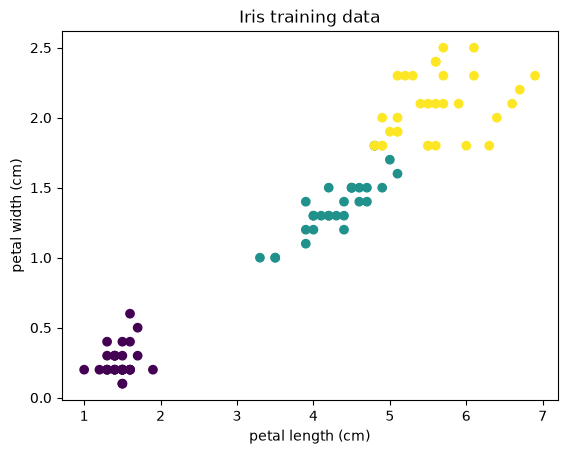

In [2]:
from matplotlib import pyplot as plt

print("Feature names:", iris.feature_names)
print("Training data:\n", X_train)
print("Training labels:\n", Y_train)

plt.scatter(X_train[:, 2], X_train[:, 3], c=Y_train)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.title("Iris training data")
plt.show()

A parametric classifier could work—for example, modelling each class with a Gaussian distribution. The classes form fairly distinct clusters, although some overlap means classification may not be perfect.

### 2. Similarity

The `euclidean` function should compute the Euclidean distance between two points (i.e. feature vectors). 

**Note:** As we are working with feature vectors, the "$\cdot$" depicts a dotproduct:

$$
d(\mathbf{p}, \mathbf{q}) = \sqrt{(\mathbf{p} - \mathbf{q})\cdot(\mathbf{p} - \mathbf{q})}
$$

In [3]:
from scipy.spatial import distance
import math 

def euclidean(p, q):
    """
    Computes the Euclidean distance between point p and q.
    :param p: point p as a numpy array.
    :param q: point q as a numpy array.
    :return: distance as float.
    """
    
    dist = math.dist(p, q)
    return dist

# Check whether your algorithm is correct
a = np.array([2, 4, 8])
b = np.array([3, 5, 9])

print('The output of your algorithm:', euclidean(a, b))
assert np.isclose(euclidean(a, b), distance.euclidean(a, b))

The output of your algorithm: 1.7320508075688772


Other distance functions: Hamming, Cosine (1 - cosine between the vetors)

### 3. Nearest Neighbours

Now that we can define a distance between points, we will try to find the $k$ (e.g. 5) nearest neighbours in the training set for a test instance. These nearest neighbours give us information about the class that a test instance is likely to belong to.

In [9]:
from queue import PriorityQueue


def get_neighbours(training_set, test_instance, k):
    """
    Calculate distances from test_instance to all training points.
    :param training_set: [n x d] numpy array of training samples (n: number of samples, d: number of dimensions).
    :param test_instance: [d x 1] numpy array of test instance features.
    :param k: number of neighbours to return.
    :return: list of length k with neighbour indices, with increasing distance of the neighbours
    """
    
    neighbours = []

    pq = PriorityQueue()

    for index, row in enumerate(training_set): 
        d = euclidean(test_instance, row)
        if pq.qsize() < k:
            pq.put((-d, index))
        else:
            farthest = pq.get()
            pq.put(max(farthest, (-d, index)))
    while not pq.empty():
        neighbours.append(pq.get()[1])
    neighbours.reverse() 
    return neighbours

neighbours = get_neighbours(X_train, X_test[0], 5)

# Check whether your algorithm is correct
print('The indices returned by your algorithm are:', neighbours)
assert neighbours == [63, 41, 76, 51, 10]

The indices returned by your algorithm are: [63, 41, 76, 51, 10]


 Verify that our implementation is correct by plotting the points in 2D:

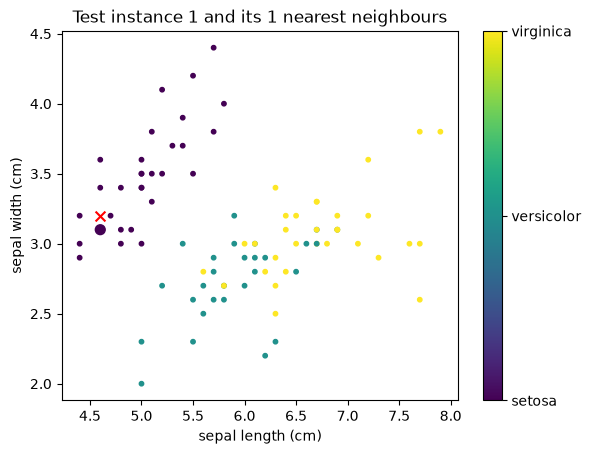

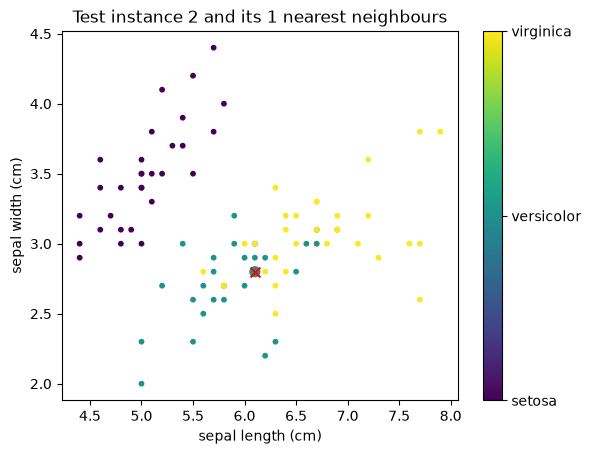

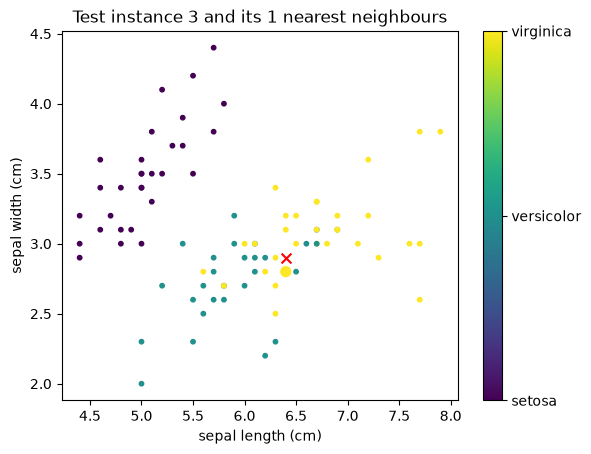

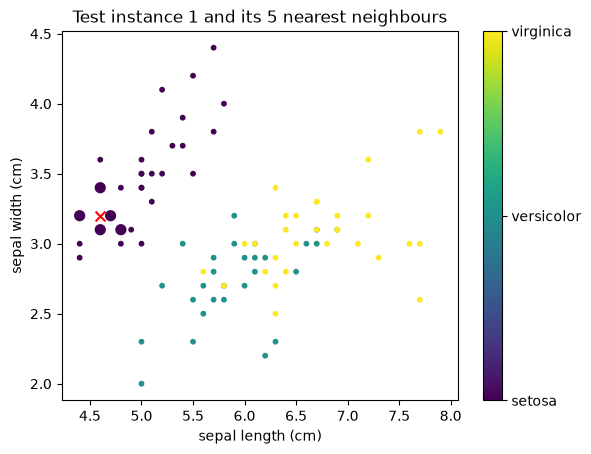

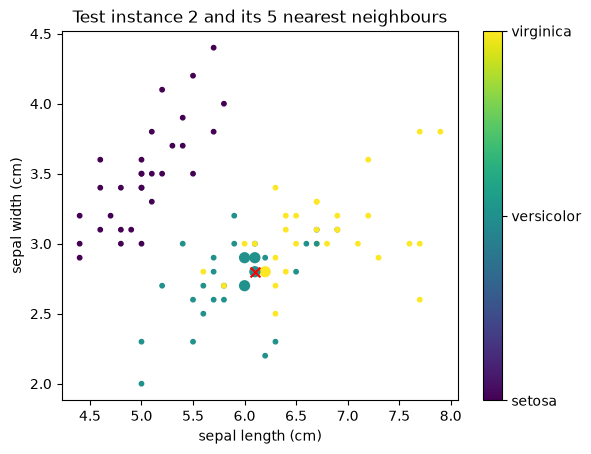

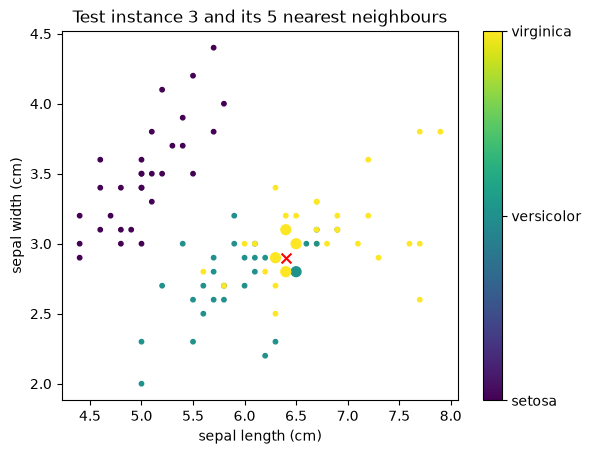

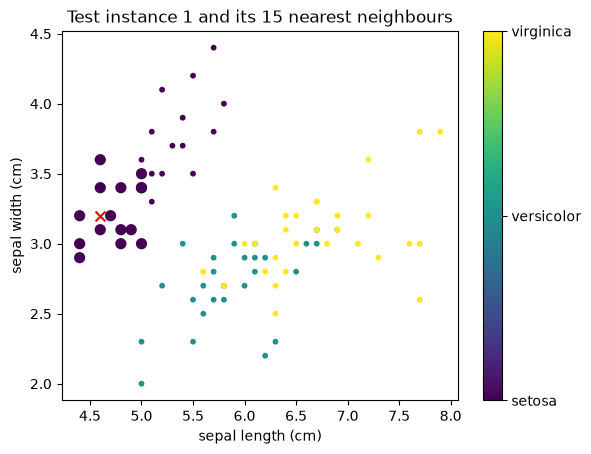

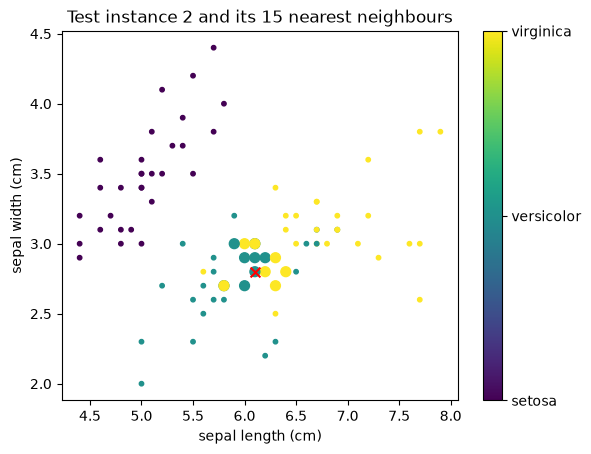

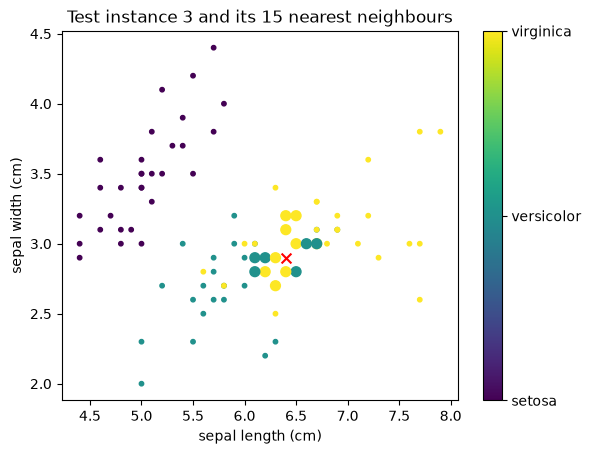

In [10]:
def plot_neighbours(X_train, Y_train, test_instance, k):
    """
    Plots all points in the dataset and shows the neighbours of a given test instance.
    """
    neighbours = get_neighbours(X_train, test_instance, k)
    # Initialization of the sizes of the points to be plotted, size 10
    neigh_sizes = np.ones((len(Y_train), 1)) * 10
    neigh_sizes[neighbours] = 50
    plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train, s=neigh_sizes)
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.colorbar(ticks=[0, 1, 2], format=plt.FuncFormatter(lambda i, *args: iris.target_names[int(i)]))
    plt.scatter(test_instance[0], test_instance[1], c='r', s=50, marker='x')
    plt.show()

for k in [1, 5, 15]:
    for i in range(3):
        test_instance = X_test[i, [0, 1]]
        plt.title('Test instance %s and its %s nearest neighbours' % (i + 1, k))
        plot_neighbours(X_train[:, [0, 1]], Y_train, test_instance, k)

### 4. Majority vote

We have the $k$ nearest neighbours of the test set. Now we will choose a class label by majority vote.

$\ex{4.1}$ Implement the `get_majority_vote` function.

_Hint:_ In the case of a split vote, pick the one that is closest.

_Hint:_ We imported a `Counter` which can help you tally up the votes.

In [13]:
from collections import Counter # To count unique occurrences of items in array, for majority voting

def get_majority_vote(neighbour_indices, training_labels):
    """
    Given an array of nearest neighbours indices for a given test case, 
    tally up their classes to vote on the correct class for the test instance.
    :param neighbours: list of nearest neighbour indices.
    :param training_labels: the list of labels for each training instance.
    :return: the label of most common class.
    """
    
    votes = Counter(np.asarray(training_labels)[neighbour_indices])
    return votes.most_common(1)[0][0]

predicted_label = get_majority_vote(neighbours, Y_train)
print('Your predicted label:', predicted_label)

assert predicted_label == 0
assert get_majority_vote([0,1,2,3,4], [0,2,2,1,3]) == 2
assert get_majority_vote([0,1,2,3,4], [3,1,1,3,0]) == 3

Your predicted label: 0


### 5. Accuracy

In [15]:
from sklearn.metrics import accuracy_score

def predict(X_train, X_test, Y_train, k=5):
    """
    Predicts all labels for the test set, using k-nn on the training set.
    :param X_train: the training set features.
    :param X_test: the test set features.
    :param y_train: the training set labels.
    :return: list of predictions.
    """

    # Generate predictions
    predictions = []

    for test_instance in X_test: 
        neighbours = get_neighbours(X_train, test_instance, k)
        predictions.append(get_majority_vote(neighbours, Y_train))
    
    return predictions

k = 5
predictions = predict(X_train, X_test, Y_train, k)

# Summarise performance of the classification using scikit-learn
accuracy = accuracy_score(Y_test, predictions)
print('The overall accuracy of the model using scikit-learn is:', accuracy)

assert predictions == [0, 1, 1, 2, 1, 1, 2, 0, 2, 0, 2, 1, 2, 0, 0, 2, 0, 1, 2, 1, 1, 2, 2, 0, 2, 1, 1, 0, 2, 2, 1, 1, 0, 0, 0, 1, 1, 0, 1, 2, 1, 2, 0, 1, 1, 0, 0, 0, 2, 0, 2, 2, 0, 2, 1, 1, 1, 0, 0, 1]
assert np.isclose(accuracy, 0.9666666666666667)

The overall accuracy of the model using scikit-learn is: 0.9666666666666667


In [17]:
def accuracy_score_self(Y_test, predictions):
    """
    Computes the accuracy of a test set as the fraction of items that was classified correctly.
    :param y_test: the list of true labels for the test set.
    :param y_pred: the list of predicted labels for the test set.
    :return: accuracy as a floating point.
    """
    
    accuracy = 0
    correct = 0

    # accuracy = number of correct predictions / total number of predictions

    for i in range(len(Y_test)):
        if(Y_test[i] == predictions[i]):
            correct += 1
    accuracy = correct / len(Y_test)
    return accuracy

# Summarise performance of the classification
accuracy_self = accuracy_score_self(Y_test, predictions)
print('The overall accuracy of the model using your implementation of accuracy:', accuracy_self)
assert np.isclose(accuracy, accuracy_self)

The overall accuracy of the model using your implementation of accuracy: 0.9666666666666667


`plot_errors` function gives a better understanding of why some points are misclassified.

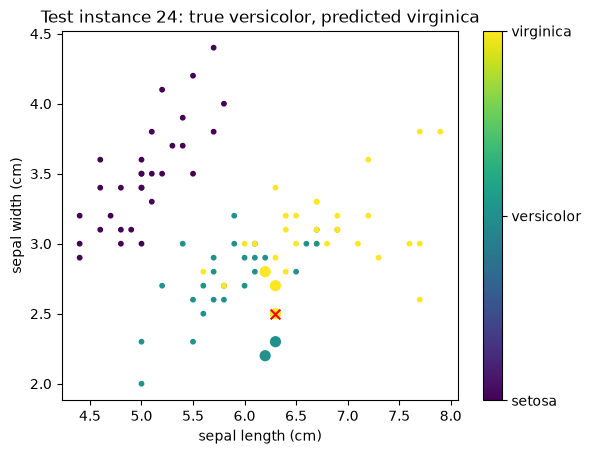

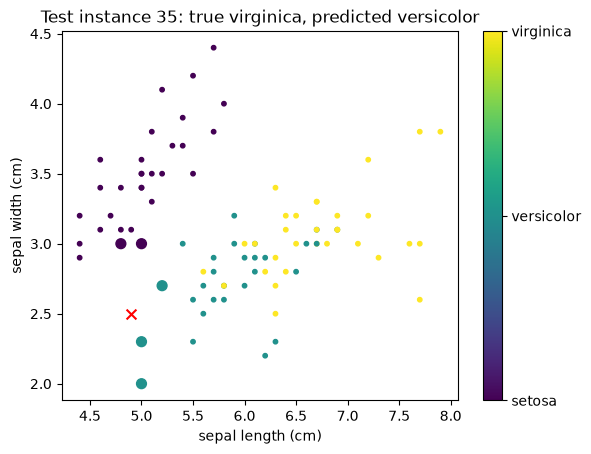

In [18]:
def plot_errors(X_train, X_test, Y_train, Y_test, predictions, k):
    """
    Plots the test points that were misclassified and their nearest neighbours using plot_neighbours.
    """
    
    for i in range(len(Y_test)):
        if predictions[i] != Y_test[i]:
            test_instance = X_test[i, [0, 1]]
            plt.title('Test instance %s: true %s, predicted %s' % (
                i, iris.target_names[Y_test[i]], iris.target_names[predictions[i]]))
            plot_neighbours(X_train[:, [0, 1]], Y_train, test_instance, k)
    return

plot_errors(X_train, X_test, Y_train, Y_test, predictions, k)